# Testing pre-trained RT-DERT model

### Setup & Install dependencies for model training

In [13]:
# @title Check if GPU enabled
!nvidia-smi

Wed Nov 12 15:52:26 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   72C    P0             32W /   70W |   15090MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [14]:
import os

HOME = os.getcwd()
print("HOME:", HOME)

from google.colab import drive
drive.mount('/content/drive')

!pip install -q git+https://github.com/huggingface/transformers.git
!pip install -q git+https://github.com/roboflow/supervision.git
!pip install -q accelerate
!pip install -q roboflow
!pip install -q torchmetrics
!pip install -q "albumentations>=1.4.5"


import torch
import requests
import math

import cv2
import numpy as np
import supervision as sv
import albumentations as A

from PIL import Image
from pprint import pprint
from roboflow import Roboflow
from dataclasses import dataclass, replace
from google.colab import userdata
from torch.utils.data import Dataset
from transformers import (
    AutoImageProcessor,
    AutoModelForObjectDetection,
    TrainingArguments,
    Trainer
)
from torchmetrics.detection.mean_ap import MeanAveragePrecision

HOME: /content
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


## Load model

In [16]:

CHECKPOINT = "PekingU/rtdetr_r50vd_coco_o365"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("cuda" if torch.cuda.is_available() else "cpu")

model = AutoModelForObjectDetection.from_pretrained(CHECKPOINT).to(DEVICE)
processor = AutoImageProcessor.from_pretrained(CHECKPOINT)

cuda


## Fine-tune RT-DETR on custom dataset

I use dataset uploaded to Roboflow. Datase contain images of drones and few quadrocopters. I tested with few bigger datasets but they weren`t accurate enought.

Disatvantages of current dataset are relatively small size (training:939, validation:266, test:134) and absence of anotated images without drones but with other objects. Like birds, planes, etc.

I am going to improve it when would have more time:)

In [17]:
# @title Download dataset from Roboflow Universe

ROBOFLOW_API_KEY = userdata.get('ROBOFLOW_API_KEY')
rf = Roboflow(api_key=ROBOFLOW_API_KEY)

project = rf.workspace("study-rea9g").project("available-dataset-2449m-iofcf")
print(project.versions)
version = project.version(3)
dataset = version.download("coco")

loading Roboflow workspace...
loading Roboflow project...
<bound method Project.versions of <roboflow.core.project.Project object at 0x7913e262e6f0>>
Exporting format coco in progress : 85.0%
Version export complete for coco format



Extracting Dataset Version Zip to Available-dataset-3 in coco:: 100%|██████████| 1347/1347 [00:01<00:00, 757.94it/s]


In [18]:
# @title Prepare dataset
ds_train = sv.DetectionDataset.from_coco(
    images_directory_path=f"{dataset.location}/train",
    annotations_path=f"{dataset.location}/train/_annotations.coco.json",
)
ds_valid = sv.DetectionDataset.from_coco(
    images_directory_path=f"{dataset.location}/valid",
    annotations_path=f"{dataset.location}/valid/_annotations.coco.json",
)
ds_test = sv.DetectionDataset.from_coco(
    images_directory_path=f"{dataset.location}/test",
    annotations_path=f"{dataset.location}/test/_annotations.coco.json",
)

print(f"Number of training images: {len(ds_train)}")
print(f"Number of validation images: {len(ds_valid)}")
print(f"Number of test images: {len(ds_test)}")

Number of training images: 939
Number of validation images: 266
Number of test images: 134


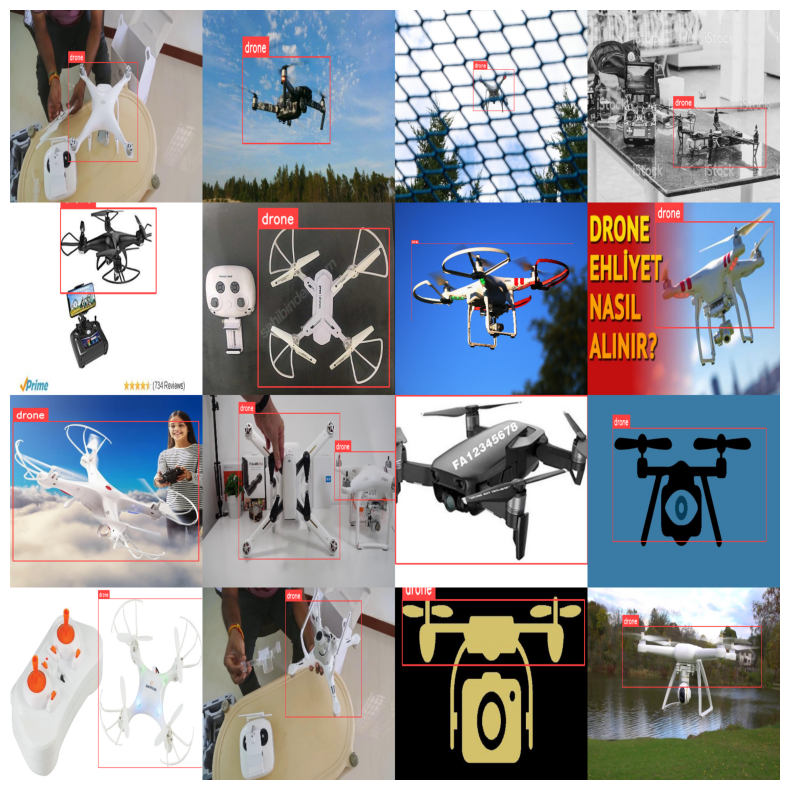

In [19]:
# @title Show image examples

GRID_SIZE = 4

def annotate(image, annotations, classes):
    # labels = [
    #   f"{model.config.id2label[class_id]} {confidence:0.2f}"
    #   for class_id, confidence in zip(detections.class_id, detections.confidence)
    # ]
    labels = [classes[class_id] for class_id in annotations.class_id]

    box_annotator = sv.BoxAnnotator()
    label_annotator = sv.LabelAnnotator(text_scale=1, text_thickness=2)

    annotated_image = image.copy()
    annotated_image = box_annotator.annotate(annotated_image, annotations)
    annotated_image = label_annotator.annotate(annotated_image, annotations, labels=labels)
    return annotated_image


# Collect annotated images
annotated_images = []
for i in range(GRID_SIZE * GRID_SIZE):
    _, image, annotations = ds_train[i]
    annotated_image = annotate(image, annotations, ds_train.classes)
    # Resize each image to a fixed size for consistent grid layout
    annotated_image = cv2.resize(annotated_image, (400, 400))
    annotated_images.append(annotated_image)


# Build grid and show images
rows = []
for i in range(GRID_SIZE):
    row_images = annotated_images[i * GRID_SIZE:(i + 1) * GRID_SIZE]
    # Concatenate images horizontally for each row
    row = np.hstack(row_images)
    rows.append(row)

grid = np.vstack(rows)
sv.plot_image(grid, size=(10, 10))

In [20]:
# @title Augmentation & Transformation

train_augmentation_and_transform = A.Compose(
    [
        A.Affine(p=0.4),
        A.Perspective(p=0.1),
        A.HorizontalFlip(p=0.5),
        # A.RandomRotate90(p=0.5),
        A.RandomBrightnessContrast(p=0.5),
        A.HueSaturationValue(p=0.1),
    ],
    bbox_params=A.BboxParams(
        format="pascal_voc",
        label_fields=["category"],
        clip=True,
        min_area=25
    ),
)

valid_transform = A.Compose(
    [A.NoOp()],
    bbox_params=A.BboxParams(
        format="pascal_voc",
        label_fields=["category"],
        clip=True,
        min_area=1
    ),
)

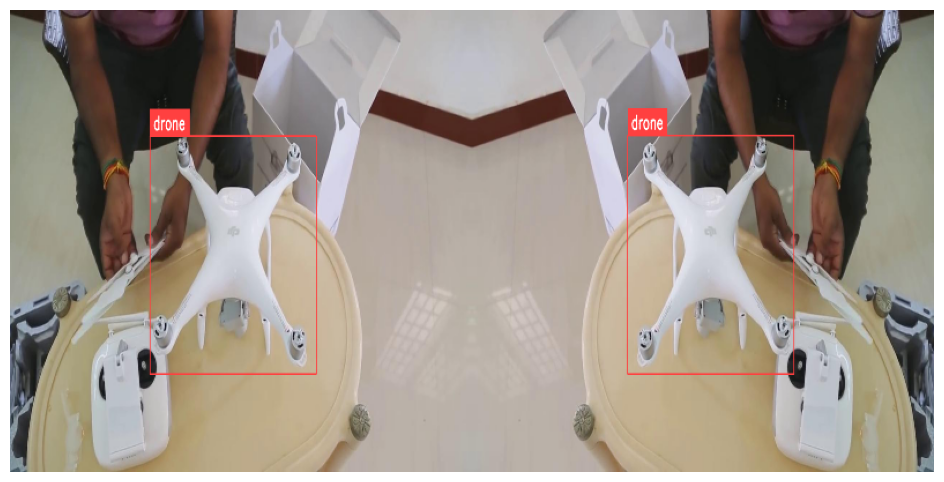

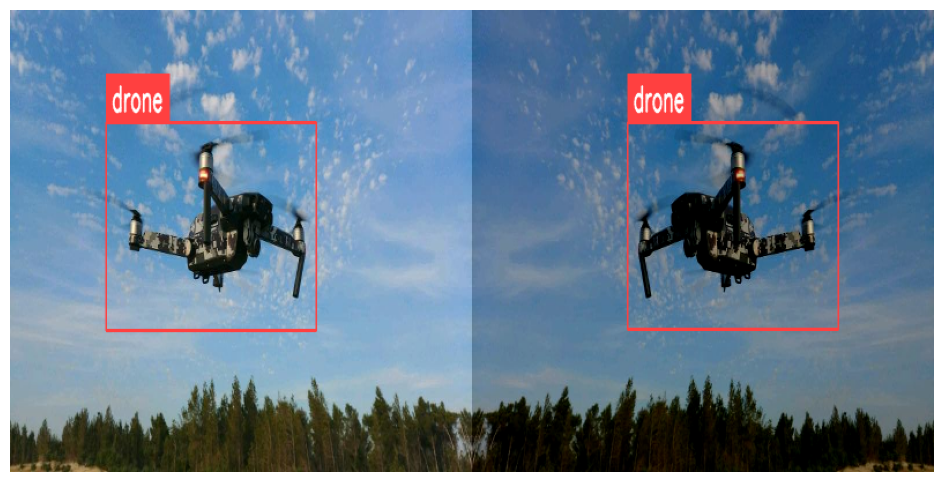

In [21]:
# @title Visualize some augmented images
IMAGE_COUNT = 2

for i in range(IMAGE_COUNT):
    _, image, annotations = ds_train[i]

    output = train_augmentation_and_transform(
        image=image,
        bboxes=annotations.xyxy,
        category=annotations.class_id
    )

    augmented_image = output["image"]
    augmented_annotations = replace(
        annotations,
        xyxy=np.array(output["bboxes"]),
        class_id=np.array(output["category"])
    )

    origin_image = cv2.resize(annotate(image, annotations, ds_train.classes), (400, 400))
    augmented_image = cv2.resize(annotate(augmented_image, augmented_annotations, ds_train.classes), (400, 400))

    grid = cv2.hconcat([origin_image, augmented_image])

    sv.plot_image(grid, size=(12, 6))

## Reformat COCO format

Reformat to format {'image_id': int, 'annotations': List[Dict]} where each dictionary is a COCO object annotation.

In [22]:
class PyTorchDetectionDataset(Dataset):
    def __init__(self, dataset: sv.DetectionDataset, processor, transform: A.Compose = None):
        self.dataset = dataset
        self.processor = processor
        self.transform = transform

    @staticmethod
    def annotations_as_coco(image_id, categories, boxes):
        annotations = []
        for category, bbox in zip(categories, boxes):
            x1, y1, x2, y2 = bbox
            formatted_annotation = {
                "image_id": image_id,
                "category_id": category,
                "bbox": [x1, y1, x2 - x1, y2 - y1],
                "iscrowd": 0,
                "area": (x2 - x1) * (y2 - y1),
            }
            annotations.append(formatted_annotation)

        return {
            "image_id": image_id,
            "annotations": annotations,
        }

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        _, image, annotations = self.dataset[idx]

        # Convert image to RGB numpy array
        image = image[:, :, ::-1]
        boxes = annotations.xyxy
        categories = annotations.class_id

        if self.transform:
            transformed = self.transform(
                image=image,
                bboxes=boxes,
                category=categories
            )
            image = transformed["image"]
            boxes = transformed["bboxes"]
            categories = transformed["category"]


        formatted_annotations = self.annotations_as_coco(
            image_id=idx, categories=categories, boxes=boxes)
        result = self.processor(
            images=image, annotations=formatted_annotations, return_tensors="pt")

        # Image processor expands batch dimension, lets squeeze it
        result = {k: v[0] for k, v in result.items()}

        return result



pytorch_dataset_train = PyTorchDetectionDataset(
    ds_train, processor, transform=train_augmentation_and_transform)
pytorch_dataset_valid = PyTorchDetectionDataset(
    ds_valid, processor, transform=valid_transform)
pytorch_dataset_test = PyTorchDetectionDataset(
    ds_test, processor, transform=valid_transform)

pytorch_dataset_train[15]

{'pixel_values': tensor([[[0.9882, 0.9922, 0.9922,  ..., 0.3020, 0.3098, 0.3098],
          [0.9725, 0.9765, 0.9765,  ..., 0.2941, 0.3059, 0.3176],
          [0.9529, 0.9569, 0.9569,  ..., 0.2863, 0.2980, 0.3098],
          ...,
          [0.2980, 0.2980, 0.3020,  ..., 0.2824, 0.2824, 0.2824],
          [0.2980, 0.3020, 0.3098,  ..., 0.2902, 0.2902, 0.2902],
          [0.2980, 0.3020, 0.3098,  ..., 0.2980, 0.2980, 0.2980]],
 
         [[0.9647, 0.9686, 0.9725,  ..., 0.2314, 0.2392, 0.2392],
          [0.9529, 0.9569, 0.9608,  ..., 0.2275, 0.2353, 0.2431],
          [0.9412, 0.9451, 0.9490,  ..., 0.2235, 0.2275, 0.2431],
          ...,
          [0.3529, 0.3529, 0.3529,  ..., 0.3373, 0.3451, 0.3490],
          [0.3490, 0.3490, 0.3490,  ..., 0.3451, 0.3529, 0.3569],
          [0.3451, 0.3451, 0.3490,  ..., 0.3529, 0.3608, 0.3647]],
 
         [[1.0000, 1.0000, 1.0000,  ..., 0.1686, 0.1647, 0.1647],
          [1.0000, 1.0000, 1.0000,  ..., 0.1725, 0.1686, 0.1804],
          [0.9961, 0.996

In [24]:
# @title Preparing function to compute mAP
id2label = {id: label for id, label in enumerate(ds_train.classes)}
label2id = {label: id for id, label in enumerate(ds_train.classes)}


@dataclass
class ModelOutput:
    logits: torch.Tensor
    pred_boxes: torch.Tensor


class MAPEvaluator:

    def __init__(self, image_processor, threshold=0.00, id2label=None):
        self.image_processor = image_processor
        self.threshold = threshold
        self.id2label = id2label

    def collect_image_sizes(self, targets):
        """Collect image sizes across the dataset as list of tensors with shape [batch_size, 2]."""
        image_sizes = []
        for batch in targets:
            batch_image_sizes = torch.tensor(np.array([x["size"] for x in batch]))
            image_sizes.append(batch_image_sizes)
        return image_sizes

    def collect_targets(self, targets, image_sizes):
        post_processed_targets = []
        for target_batch, image_size_batch in zip(targets, image_sizes):
            for target, (height, width) in zip(target_batch, image_size_batch):
                boxes = target["boxes"]
                boxes = sv.xcycwh_to_xyxy(boxes)
                boxes = boxes * np.array([width, height, width, height])
                boxes = torch.tensor(boxes)
                labels = torch.tensor(target["class_labels"])
                post_processed_targets.append({"boxes": boxes, "labels": labels})
        return post_processed_targets

    def collect_predictions(self, predictions, image_sizes):
        post_processed_predictions = []
        for batch, target_sizes in zip(predictions, image_sizes):
            batch_logits, batch_boxes = batch[1], batch[2]
            output = ModelOutput(logits=torch.tensor(batch_logits), pred_boxes=torch.tensor(batch_boxes))
            post_processed_output = self.image_processor.post_process_object_detection(
                output, threshold=self.threshold, target_sizes=target_sizes
            )
            post_processed_predictions.extend(post_processed_output)
        return post_processed_predictions

    @torch.no_grad()
    def __call__(self, evaluation_results):

        predictions, targets = evaluation_results.predictions, evaluation_results.label_ids

        image_sizes = self.collect_image_sizes(targets)
        post_processed_targets = self.collect_targets(targets, image_sizes)
        post_processed_predictions = self.collect_predictions(predictions, image_sizes)

        evaluator = MeanAveragePrecision(box_format="xyxy", class_metrics=True)
        evaluator.warn_on_many_detections = False
        evaluator.update(post_processed_predictions, post_processed_targets)

        metrics = evaluator.compute()

        # Replace list of per class metrics with separate metric for each class
        classes = metrics.pop("classes")
        map_per_class = metrics.pop("map_per_class")
        mar_100_per_class = metrics.pop("mar_100_per_class")
        for class_id, class_map, class_mar in zip(classes, map_per_class, mar_100_per_class):
            class_name = id2label[class_id.item()] if id2label is not None else class_id.item()
            metrics[f"map_{class_name}"] = class_map
            metrics[f"mar_100_{class_name}"] = class_mar

        metrics = {k: round(v.item(), 4) for k, v in metrics.items()}

        return metrics


def collate_fn(batch):
    data = {}
    data["pixel_values"] = torch.stack([x["pixel_values"] for x in batch])
    data["labels"] = [x["labels"] for x in batch]
    return data

# ------------------------------------------------------------------------------------------
# ------------------------------------------------------------------------------------------

model = AutoModelForObjectDetection.from_pretrained(
    CHECKPOINT,
    id2label=id2label,
    label2id=label2id,
    anchor_image_size=None,
    ignore_mismatched_sizes=True,
)

# Preprocess data
IMAGE_SIZE = 480

processor = AutoImageProcessor.from_pretrained(
    CHECKPOINT,
    do_resize=True,
    size={"width": IMAGE_SIZE, "height": IMAGE_SIZE},
)


eval_compute_metrics_fn = MAPEvaluator(image_processor=processor, threshold=0.01, id2label=id2label)

Some weights of RTDetrForObjectDetection were not initialized from the model checkpoint at PekingU/rtdetr_r50vd_coco_o365 and are newly initialized because the shapes did not match:
- model.decoder.class_embed.0.bias: found shape torch.Size([80]) in the checkpoint and torch.Size([2]) in the model instantiated
- model.decoder.class_embed.0.weight: found shape torch.Size([80, 256]) in the checkpoint and torch.Size([2, 256]) in the model instantiated
- model.decoder.class_embed.1.bias: found shape torch.Size([80]) in the checkpoint and torch.Size([2]) in the model instantiated
- model.decoder.class_embed.1.weight: found shape torch.Size([80, 256]) in the checkpoint and torch.Size([2, 256]) in the model instantiated
- model.decoder.class_embed.2.bias: found shape torch.Size([80]) in the checkpoint and torch.Size([2]) in the model instantiated
- model.decoder.class_embed.2.weight: found shape torch.Size([80, 256]) in the checkpoint and torch.Size([2, 256]) in the model instantiated
- model.

# Training the detection model

In [25]:
training_args = TrainingArguments(
    logging_strategy="epoch",
    report_to="tensorboard",
    output_dir=f"{dataset.name.replace(' ', '-')}-finetune",
    num_train_epochs=20,
    max_grad_norm=0.1,
    learning_rate=5e-5,
    warmup_steps=300,
    per_device_train_batch_size=16,
    dataloader_num_workers=2,
    metric_for_best_model="eval_map",
    greater_is_better=True,
    load_best_model_at_end=True,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    remove_unused_columns=False,
    eval_do_concat_batches=False,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=pytorch_dataset_train,
    eval_dataset=pytorch_dataset_valid,
    processing_class=processor,
    data_collator=collate_fn,
    compute_metrics=eval_compute_metrics_fn,
)

trainer.train()

Epoch,Training Loss,Validation Loss,Map,Map 50,Map 75,Map Small,Map Medium,Map Large,Mar 1,Mar 10,Mar 100,Mar Small,Mar Medium,Mar Large,Map Ouadcopter,Mar 100 Ouadcopter,Map Drone,Mar 100 Drone
1,545.601000,255.082062,0.007300,0.014000,0.010900,0.000000,0.000000,0.010700,0.016100,0.050000,0.093500,0.000000,0.080000,0.096600,-1.000000,-1.000000,0.007300,0.093500
2,122.457800,42.558743,0.142600,0.273400,0.127200,0.002100,0.022600,0.298800,0.268200,0.584200,0.671600,0.133300,0.365000,0.706800,-1.000000,-1.000000,0.142600,0.671600
3,44.615100,26.001156,0.179400,0.314300,0.183400,0.012400,0.044200,0.231500,0.407900,0.633200,0.727700,0.216700,0.435000,0.761300,-1.000000,-1.000000,0.179400,0.727700
4,28.331000,14.239236,0.583700,0.925800,0.647100,0.210700,0.353300,0.611300,0.599300,0.706200,0.758600,0.316700,0.555000,0.783800,-1.000000,-1.000000,0.583700,0.758600
5,20.840500,11.465796,0.621000,0.939700,0.693300,0.401800,0.503200,0.639200,0.625700,0.727700,0.781200,0.433300,0.610000,0.801900,-1.000000,-1.000000,0.621000,0.781200
6,18.894600,10.070118,0.653600,0.959200,0.719400,0.375500,0.527800,0.674900,0.646200,0.752700,0.801400,0.383300,0.655000,0.821800,-1.000000,-1.000000,0.653600,0.801400
7,17.246800,9.096098,0.678000,0.967100,0.789900,0.392900,0.479100,0.700500,0.668200,0.760600,0.813700,0.416700,0.665000,0.833800,-1.000000,-1.000000,0.678000,0.813700
8,16.000100,9.081404,0.674900,0.970600,0.783500,0.477600,0.549200,0.690800,0.665100,0.759600,0.828400,0.483300,0.655000,0.849200,-1.000000,-1.000000,0.674900,0.828400
9,15.176800,8.754853,0.685100,0.971600,0.799200,0.417800,0.478900,0.710100,0.658200,0.754100,0.817800,0.416700,0.650000,0.839500,-1.000000,-1.000000,0.685100,0.817800
10,14.879000,8.882170,0.674200,0.968700,0.766600,0.492600,0.442400,0.696900,0.662300,0.738400,0.812700,0.500000,0.660000,0.831200,-1.000000,-1.000000,0.674200,0.812700


There were missing keys in the checkpoint model loaded: ['class_embed.0.weight', 'class_embed.0.bias', 'class_embed.1.weight', 'class_embed.1.bias', 'class_embed.2.weight', 'class_embed.2.bias', 'class_embed.3.weight', 'class_embed.3.bias', 'class_embed.4.weight', 'class_embed.4.bias', 'class_embed.5.weight', 'class_embed.5.bias', 'bbox_embed.0.layers.0.weight', 'bbox_embed.0.layers.0.bias', 'bbox_embed.0.layers.1.weight', 'bbox_embed.0.layers.1.bias', 'bbox_embed.0.layers.2.weight', 'bbox_embed.0.layers.2.bias', 'bbox_embed.1.layers.0.weight', 'bbox_embed.1.layers.0.bias', 'bbox_embed.1.layers.1.weight', 'bbox_embed.1.layers.1.bias', 'bbox_embed.1.layers.2.weight', 'bbox_embed.1.layers.2.bias', 'bbox_embed.2.layers.0.weight', 'bbox_embed.2.layers.0.bias', 'bbox_embed.2.layers.1.weight', 'bbox_embed.2.layers.1.bias', 'bbox_embed.2.layers.2.weight', 'bbox_embed.2.layers.2.bias', 'bbox_embed.3.layers.0.weight', 'bbox_embed.3.layers.0.bias', 'bbox_embed.3.layers.1.weight', 'bbox_embed.3.l

TrainOutput(global_step=1180, training_loss=48.388173610881225, metrics={'train_runtime': 3894.784, 'train_samples_per_second': 4.822, 'train_steps_per_second': 0.303, 'total_flos': 5.916489869131776e+18, 'train_loss': 48.388173610881225, 'epoch': 20.0})

# Collect predictions & Calculate mAP

In [26]:
# collect predictions
targets = []
predictions = []

for i in range(len(ds_test)):
    path, sourece_image, annotations = ds_test[i]

    image = Image.open(path)
    inputs = processor(image, return_tensors="pt").to(DEVICE)

    with torch.no_grad():
        outputs = model(**inputs)

    w, h = image.size
    results = processor.post_process_object_detection(
        outputs, target_sizes=[(h, w)], threshold=0.3)

    detections = sv.Detections.from_transformers(results[0])

    targets.append(annotations)
    predictions.append(detections)


# calculate mean accuracy
mean_average_precision = sv.MeanAveragePrecision.from_detections(
    predictions=predictions,
    targets=targets,
)

print(f"map50_95: {mean_average_precision.map50_95:.2f}")
print(f"map50: {mean_average_precision.map50:.2f}")
print(f"map75: {mean_average_precision.map75:.2f}")

print(outputs.logits.shape, outputs.pred_boxes.shape)
print(f"softmax output: {outputs.logits[0].softmax(-1).max().item():.2f}")

map50_95: 0.72
map50: 0.97
map75: 0.84
torch.Size([1, 300, 2]) torch.Size([1, 300, 4])
softmax output: 1.00


MeanAveragePrecision is deprecated: `MeanAveragePrecision` is deprecated and will be removed in `supervision-0.31.0`. Use `supervision.metrics.mean_average_precision.MeanAveragePrecision` instead. The deprecated implementation provides results that are inconsistent with pycocotools.


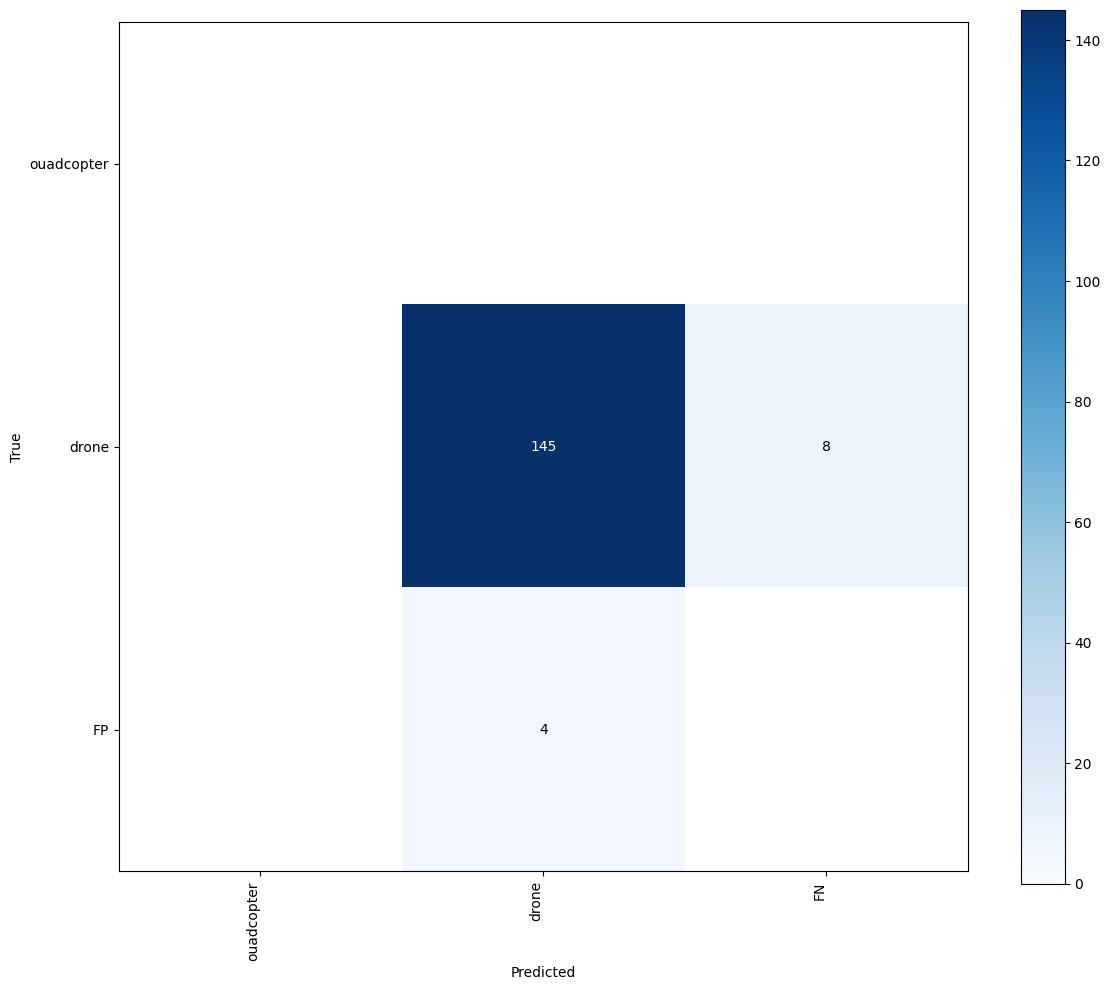

In [27]:
# @title Calculate Confusion Matrix
confusion_matrix = sv.ConfusionMatrix.from_detections(
    predictions=predictions,
    targets=targets,
    classes=ds_test.classes
)

_ = confusion_matrix.plot()

In [28]:
# @title Save pretrained model
model.save_pretrained("/content/rt-detr/")
processor.save_pretrained("/content/rt-detr/")

['/content/rt-detr/preprocessor_config.json']

# Testing Detectiond & Tracking
Initial test setup

In [29]:
!pip install -q mss

import mss
import numpy as np
import cv2
from google.colab.patches import cv2_imshow
from PIL import Image
from IPython.display import Video
from transformers import AutoModelForObjectDetection, AutoImageProcessor
import torch

FINETUNED_MODEL_DIR = "/content/rt-detr"  # or latest checkpoint path
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

processor = AutoImageProcessor.from_pretrained(FINETUNED_MODEL_DIR)
model = AutoModelForObjectDetection.from_pretrained(FINETUNED_MODEL_DIR).to(DEVICE)

# Test detection
I tested detection on image that wasnt included into dataset

drone: 0.90, box=[280.9289245605469, 182.8530731201172, 458.37994384765625, 252.6803741455078]
drone: 0.89, box=[196.55291748046875, 279.1967468261719, 302.6566162109375, 324.0314025878906]
drone: 0.87, box=[474.6539001464844, 227.1489715576172, 549.9567260742188, 263.60260009765625]
drone: 0.85, box=[80.02139282226562, 114.2625961303711, 272.7774353027344, 196.1803436279297]
drone: 0.70, box=[345.616943359375, 74.25952911376953, 461.203125, 126.23095703125]
drone: 0.33, box=[205.29934692382812, 72.24040222167969, 285.8764953613281, 115.17865753173828]


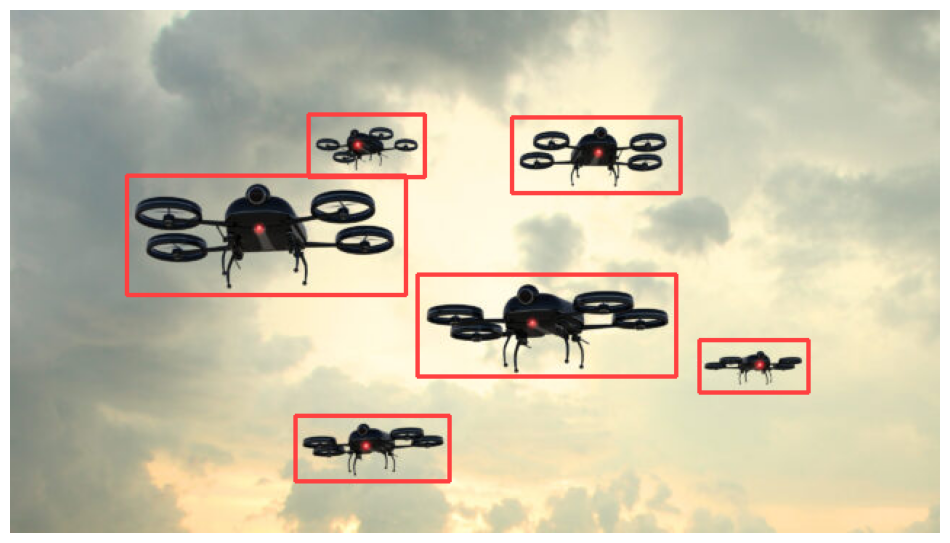

In [34]:
TEST_IMAGE_URL = "https://epic.org/wp-content/uploads/fly-images/23043/aerial-surveillance-drones-scaled-640x360-c.jpg"

image = Image.open(requests.get(TEST_IMAGE_URL, stream=True).raw).convert("RGB")
inputs = processor(image, return_tensors="pt").to(DEVICE)

# we do not need gradient
with torch.no_grad():
    outputs = model(**inputs)

w, h = image.size
results = processor.post_process_object_detection(
    outputs, target_sizes=[(h, w)], threshold=0.3  # lower threshold if needed
)[0]


for score, label, box in zip(results["scores"], results["labels"], results["boxes"]):
    label_name = model.config.id2label[label.item()]
    print(f"{label_name}: {score:.2f}, box={box.tolist()}")

detections = sv.Detections.from_transformers(results)
annotator = sv.BoxAnnotator()
annotated_frame = annotator.annotate(scene=image, detections=detections)
sv.plot_image(annotated_frame)

# Test tracking on video
Test traking on recorded video store annotated video

In [33]:
video_path = "/content/drive/MyDrive/Colab Notebooks/drone-1.mp4"
cap = cv2.VideoCapture(video_path)

# === Prepare output ===
save_path = "/content/annotated_drone.mp4"
fps = int(cap.get(cv2.CAP_PROP_FPS))
width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fourcc = cv2.VideoWriter_fourcc(*"mp4v")
writer = cv2.VideoWriter(save_path, fourcc, fps, (width, height))

annotator = sv.BoxAnnotator()

while True:
    ret, frame = cap.read()
    if not ret:
        break

    image = Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    inputs = processor(images=image, return_tensors="pt").to(DEVICE)

    with torch.no_grad():
        outputs = model(**inputs)

    results = processor.post_process_object_detection(
        outputs,
        threshold=0.3,
        target_sizes=[image.size[::-1]]
    )[0]

    detections = sv.Detections.from_transformers(results)
    annotated_frame = annotator.annotate(scene=frame.copy(), detections=detections)

    writer.write(annotated_frame)

cap.release()
writer.release()

print(f"saved annotated video to: {save_path}")
Video(save_path, embed=True)

Output hidden; open in https://colab.research.google.com to view.